[0.11280493 0.11222922 0.11186297 0.1116498  0.11146164 0.11053285
 0.1103928  0.10979734 0.10926847]
1.0000000000000002


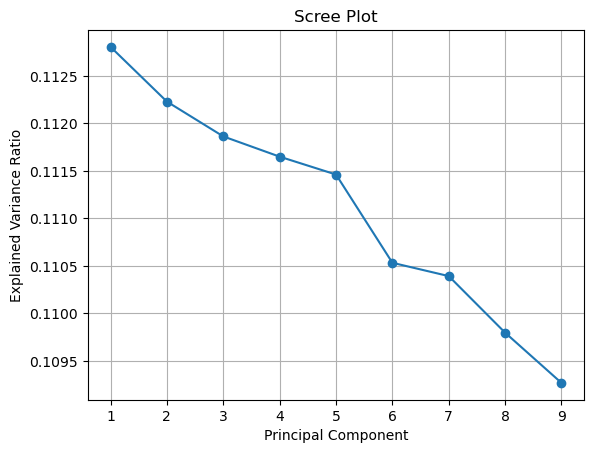

In [51]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("../data/manufacturing_6G_dataset.csv")

features = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%',
    'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr',
    'Predictive_Maintenance_Score',
    'Error_Rate_%'
]

X = df[features]
# print(X)
# Step 1: Standardization
scaler = StandardScaler()
# print(scaler)
X_scaled = scaler.fit_transform(X)
# print(X_scaled)
# Step 2: Apply PCA




pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))
# cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# print(cumulative_variance)
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_,
         marker='o')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()



# Convert to DataFrame
# pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'])

# # Add label for interpretation
# pca_df['Efficiency_Status'] = df['Efficiency_Status']

# # Plot
# plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.title("PCA - Machine Behavior")
# plt.show()



In [52]:
## HOW MUCH INFORMATION DID WE RETAIN?
print(pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

loadings = pd.DataFrame(
    pca.components_,
    columns=features
)

print(loadings.abs())


# ‘’’
# For example if your output from loadings ……: 
# If PC1 has high values for:
# Temperature 
# Power 
# Vibration 
# PC1 = Machine Stress / Load

# If PC2 has high values for:
# Latency 
# Packet Loss 
# PC2 = Network/System Issues
# ‘’’


[0.11280493 0.11222922 0.11186297 0.1116498  0.11146164 0.11053285
 0.1103928  0.10979734 0.10926847]
Total variance captured: 1.0000000000000002
   Temperature_C  Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  \
0       0.073682      0.388031              0.213921            0.283927   
1       0.438015      0.008739              0.426994            0.539397   
2       0.242893      0.586636              0.222123            0.440729   
3       0.327202      0.334830              0.088834            0.232111   
4       0.364075      0.034944              0.499383            0.057815   
5       0.319723      0.091368              0.306992            0.090514   
6       0.600837      0.087513              0.524381            0.152049   
7       0.201826      0.492431              0.189182            0.195379   
8       0.011926      0.365220              0.245544            0.554520   

   Packet_Loss_%  Quality_Control_Defect_Rate_%  \
0       0.376405                       0.1

In [ ]:
# Data is high-dimensional and evenly distributed
# Each feature carries similar importance